In [10]:
## Visualize Cross sections

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import cartopy.crs as crs
from cartopy.feature import NaturalEarthFeature
from netCDF4 import Dataset

from wrf import to_np, getvar, CoordPair, vertcross

#to get a list of the files in the folder
import glob 

## General Goals

Drawing from visuals listed in the wrf pythong examples, want to get some visual looks at wind speed and potentially pressure from cross sections

I am not sure how exactly to choose the cross sectional locations or the times, but thinking we can pull a few time windows and a few cross sections and get a sense for things that way

Page to reference: https://wrf-python.readthedocs.io/en/latest/plot.html#cross-section-with-mountains

In [6]:
d02_2017_names = glob.glob("../../01Data/Houston_MarineHeatWave_2017/wrfout_MarineHeatWave.d02.*")
#d02_2017_climavg_names  = glob.glob("../../01Data/Houston_MarineHeatWave_2017_w16SST/wrfout_MarineHeatWave.d02.*")

ncfile = Dataset(d02_2017_names[19])

In [14]:
# Create the start point and end point for the cross section
##urban
start_point1 = CoordPair(lat=29.32, lon=-94.92)
end_point1 = CoordPair(lat=30.32, lon=-96.09)

##to the east of Houston
start_point2 = CoordPair(lat=29.64, lon=-94.18)
end_point2 = CoordPair(lat=30.49, lon=-94.75)

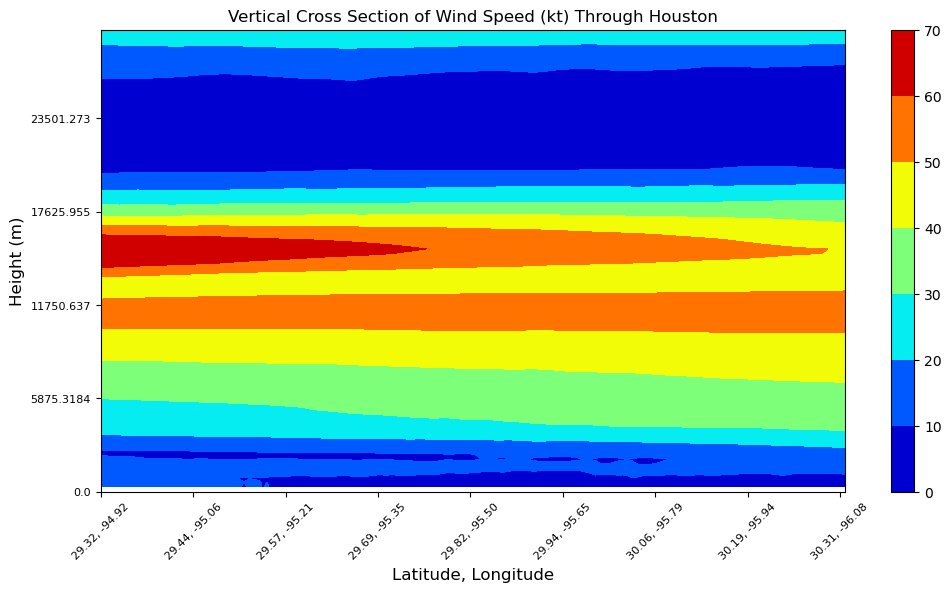

In [15]:
# Extract the model height and wind speed
z = getvar(ncfile, "z")
wspd =  getvar(ncfile, "uvmet_wspd_wdir", units="kt")[0,:]

# Compute the vertical cross-section interpolation.  Also, include the
# lat/lon points along the cross-section.
wspd_cross = vertcross(wspd, z, wrfin=ncfile, start_point=start_point1,
                       end_point=end_point1, latlon=True, meta=True)

# Create the figure
fig = plt.figure(figsize=(12,6))
ax = plt.axes()

# Make the contour plot
wspd_contours = ax.contourf(to_np(wspd_cross), cmap=matplotlib.colormaps['jet'])

# Add the color bar
plt.colorbar(wspd_contours, ax=ax)

# Set the x-ticks to use latitude and longitude labels.
coord_pairs = to_np(wspd_cross.coords["xy_loc"])
x_ticks = np.arange(coord_pairs.shape[0])
x_labels = [pair.latlon_str(fmt="{:.2f}, {:.2f}")
            for pair in to_np(coord_pairs)]
ax.set_xticks(x_ticks[::20])
ax.set_xticklabels(x_labels[::20], rotation=45, fontsize=8)

# Set the y-ticks to be height.
vert_vals = to_np(wspd_cross.coords["vertical"])
v_ticks = np.arange(vert_vals.shape[0])
ax.set_yticks(v_ticks[::20])
ax.set_yticklabels(vert_vals[::20], fontsize=8)

# Set the x-axis and  y-axis labels
ax.set_xlabel("Latitude, Longitude", fontsize=12)
ax.set_ylabel("Height (m)", fontsize=12)

plt.title("Vertical Cross Section of Wind Speed (kt) Through Houston")

plt.show()

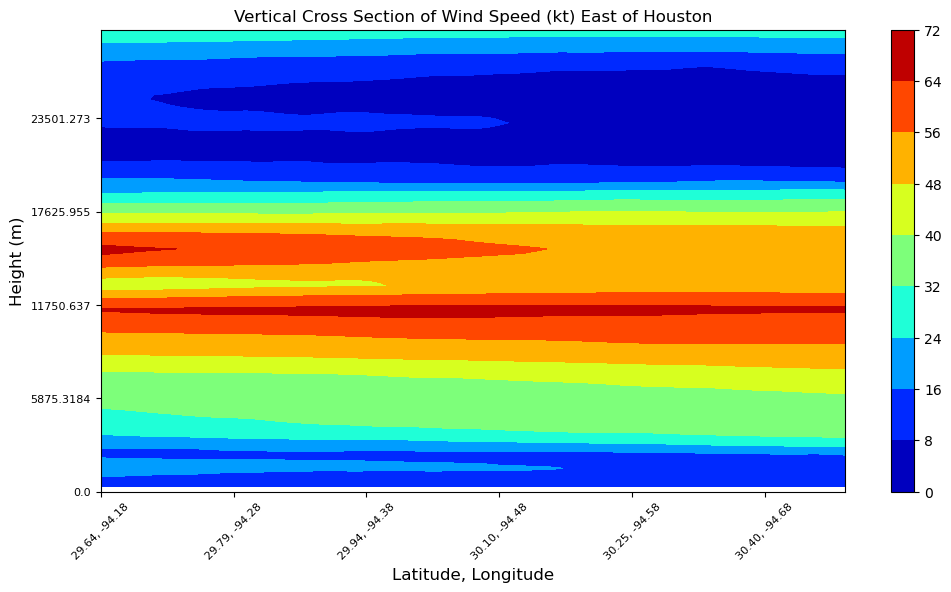

In [16]:
# Extract the model height and wind speed
z = getvar(ncfile, "z")
wspd =  getvar(ncfile, "uvmet_wspd_wdir", units="kt")[0,:]

# Compute the vertical cross-section interpolation.  Also, include the
# lat/lon points along the cross-section.
wspd_cross = vertcross(wspd, z, wrfin=ncfile, start_point=start_point2,
                       end_point=end_point2, latlon=True, meta=True)

# Create the figure
fig = plt.figure(figsize=(12,6))
ax = plt.axes()

# Make the contour plot
wspd_contours = ax.contourf(to_np(wspd_cross), cmap=matplotlib.colormaps['jet'])

# Add the color bar
plt.colorbar(wspd_contours, ax=ax)

# Set the x-ticks to use latitude and longitude labels.
coord_pairs = to_np(wspd_cross.coords["xy_loc"])
x_ticks = np.arange(coord_pairs.shape[0])
x_labels = [pair.latlon_str(fmt="{:.2f}, {:.2f}")
            for pair in to_np(coord_pairs)]
ax.set_xticks(x_ticks[::20])
ax.set_xticklabels(x_labels[::20], rotation=45, fontsize=8)

# Set the y-ticks to be height.
vert_vals = to_np(wspd_cross.coords["vertical"])
v_ticks = np.arange(vert_vals.shape[0])
ax.set_yticks(v_ticks[::20])
ax.set_yticklabels(vert_vals[::20], fontsize=8)

# Set the x-axis and  y-axis labels
ax.set_xlabel("Latitude, Longitude", fontsize=12)
ax.set_ylabel("Height (m)", fontsize=12)

plt.title("Vertical Cross Section of Wind Speed (kt) East of Houston")

plt.show()